# Generate amorphous LSU networks

This notebook demonstrates `generate_lsu_network`, which implements the
Wooten-Winer-Weaire simulated annealing algorithm of Sellers et al.
(*Nat. Commun.* **8**, 14439, 2017) on a periodic 3-regular graph.

Documentation: see the `claude_context/` folder.

**Inputs**: target LSU (`lsu_degree_12` or `lsu_degree_22`), one of
(`num_vertices` or `num_rods`), `bounds_microns`.

**Output**: NumPy array `(R, 6)` where each row is `[x1, y1, z1, x2, y2, z2]` —
directly usable in the `create_permittivity_grid_penlike` pipeline. With the
default `pbc_duplicate_boundary_rods=True`, `R` equals the unique-edge count
plus the number of edges crossing box faces (each rendered twice, once from
each canonical-box endpoint), matching the Sellers reference file convention.

In [ ]:
import numpy as np
import lsu_network as lsu
import jax 
from datetime import datetime
import os
import platform

today = datetime.today()
formatted = today.strftime("%Y%m%d")

print('JAX available:', lsu.HAS_JAX)
print("Devices:", jax.devices())

def shutdown(delay_minutes=1):
    os.system(f"sudo shutdown -h +{delay_minutes}")
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5" 

JAX available: True
Devices: [CudaDevice(id=0)]


In [2]:
D0, N = 0.8, 1000
BOX = (N/1000 * 11.44**3)**(1/3)

## Reproduce the example: amorphous LSU network from a RANDOM seed, N=1000

The reference (`Example/lsu_example_ends.txt`) is a **globally amorphous**,
**locally LSU-ordered** trivalent network: Φ₁₂ ≈ 0.985, Φ₂₂ ≈ 0.889
(this repo's `compute_lsu` reads 0.9849 / 0.8887), **N=1000 vertices, 1500
unique edges**, periodicity 11.44 µm, mean rod 0.8 µm, **nearly hyperuniform**
(S_low_k2 ≈ 0.053, α(k<2) ≈ +1.5), and — the decisive property — a vertex
structure factor S_v(k) with **NO Bragg peaks** (peak ≈ 1.8).

**Recipe (validated 2026-06-23): RANDOM seed → extended pure-WWW anneal → free
void fix.** This is Sellers/Florescu's published direction (random/liquid start
→ anneal), reproduced here from a random seed:

1. **`random_bm2000` seed** — a random/liquid start (their patent: "start from a
   liquid-like configuration to avoid memory of an initial crystalline state").
2. **Extended slow-cool pure WWW** (w=0, Keating, **~250 moves/atom**): clears
   the local-order plateau — Φ₂₂ 0.844→0.88, bond-angle std 11.6°→reference
   level — by healing odd-ring defects. The earlier wall was simply
   **UNDER-annealing** (short anneals froze at Φ₂₂ ~0.84 / 8r ~38); extended
   annealing reaches reference-level local order.
3. **Sustained hold at the ordering T=0.04** — settles bond angles to reference
   level and holds the 8-rings (equilibrium ~52; gold's 60 is the high tail).
4. **Stage-B** — a *free* fixed-topology low-k optimisation restores
   hyperuniformity. (The void does **not** emerge from the pure anneal — it
   needs the explicit low-k objective, applied here as a zero-topology-cost
   post-process.)

`generate_from_random()` runs all four steps end-to-end. **NOTE: this is a long
computation** (~250–300 moves/atom of WWW annealing): ~hours on the scipy path,
~1/3 of that with `fast=True` (the integration-parity-validated on-device path,
N=1000 + this schedule only). The **pre-computed result** is
`Example/20260623_lsu_fromrandom_N1000_ends.txt` (passes all hard gates — see its
`_README.md`). The old crystal-melt route (cells below, commented out) also
yields an amorphous network but is a different, gyroid-derived path. Energy
weights `alpha=0.7,beta=0.7,gamma=0.3,delta=0.4` are Sellers-group confirmed —
do not change.


In [ ]:
# # =====================================================================
# # RECOMMENDED PRODUCTION RECIPE  -- MELT then ANNEAL  (revised 2026-06-15)
# # =====================================================================
# # Goal: a GLOBALLY AMORPHOUS, locally LSU-ordered network matching
# # Example/lsu_example_ends.txt:  Phi_22 ~= 0.89, Phi_12 ~= 0.98, bonds
# # 0.80 um, rings peaked on 8 (girth 6), nearly hyperuniform (S_low_k2 ~= 0.05,
# # alpha(k<2) ~= +1.5), and -- the decisive property -- a vertex structure
# # factor S_v(k) with NO Bragg peaks (reference S_v peak ~= 1.8, not the
# # crystal's 8.5). The 'Verify' cells below print that S_v Bragg gate.
# #
# # DIRECTION = disorder -> LSU-order (the correct WWW direction).
# #   1. SEED: the srs (single-gyroid) crystal -- used only as a convenient
# #      connected, girth-clean, degree-3 graph.
# #   2. MELT (burn-in): a strong heat/cool/quench at 5.0x the Hemmann melt
# #      temperature DESTROYS the crystal's global (Bragg) order. Verified on an
# #      N=512 smoke (same density): S_v peak 8.5->1.7, girth 10->6, rings
# #      respread to 6..10 peaked on 8 -- a real topological rewiring, not a
# #      geometric jitter. This is what makes the output GLOBALLY AMORPHOUS.
# #   3. ANNEAL (production WWW): a SUSTAINED moderate-T anneal raises Phi in the
# #      LSU sense while a STRONG low-k uniformity guard (uniformity_weight=15)
# #      suppresses the large voids an over-melt would leave.
# #
# # VERIFIED N=512 smoke result vs reference (globally amorphous, no Bragg):
# #   Phi_12=0.987 (ref 0.985), Phi_22=0.882 (ref 0.889), S_low_k2=0.076
# #   (ref 0.053), alpha(k<2)=+1.65 (ref +1.51), girth 6, ring-peak 8,
# #   dihedral entropy 0.85 (ref 0.80), delta_c=1.60 (ref 1.59),
# #   S_v peak 1.75 / 0 Bragg (ref 1.82 / 0).
# #
# # THE ANNEAL SCHEDULE MATTERS (verified by two N=512 smokes):
# #   Phi is NOT a term in the Metropolis objective (it is strain_energy +
# #   uniformity_weight*S_low; Phi is only the early-exit readout) -- high Phi
# #   EMERGES from low Sellers strain energy via ring-rewiring Stone-Wales
# #   moves, which carry a high barrier. A DEEP cool (0.07->1e-3) freezes those
# #   moves out below T~=0.012 and the topology locks early: Phi_22 plateaus at
# #   0.868, S_low 0.089. A SUSTAINED moderate-T anneal (0.05->0.02, ~2x the
# #   iterations) keeps the ring moves clearing their barrier for longer and
# #   reaches Phi_22=0.882 AND a better S_low=0.076 -- the schedule used below.
# #   To chase the last ~0.007 of Phi: run more iterations and/or slow the melt
# #   cool (raise burn_in_n_cool) so more 8-rings form. Do NOT try to weight Phi
# #   directly -- there is no Phi term in the objective to weight.
# #
# # REJECTED earlier recipe (for the record): crystal seed + light disorder
# # (initial_temperature=0.22, no burn-in) 'snaps' Phi down from 1.0 to 0.89 in
# # ~40 s, BUT leaves S_v peak 4.75 with 2 Bragg peaks -- still globally
# # CRYSTALLINE. Matching Phi alone is a trap; the melt is what kills Bragg.
# #
# # Energy weights alpha=0.7,beta=0.7,gamma=0.3,delta=0.4: Sellers-group
# # confirmed -- do not change. The direction-aware early-exit fix in
# # www_anneal lets production rise from the melted Phi (~0.86) toward target.


# rods = lsu.generate_lsu_network(
#     lsu_degree_22=0.89,                 # type-2 amorphous gyroid target
#     num_vertices=N,                  # matches Example/lsu_example_ends.txt
#     bounds_microns=BOX,
#     edge_length=D0,

#     # --- Seed: srs crystal (just a clean connected degree-3 graph) ---
#     seed_kind='crystal_srs',
#     seed_lattice='srs',
#     seed_jitter_sigma=0.12,

#     # --- MELT (burn-in): destroy the crystal's global Bragg order ----------
#     #     Move counts scaled ~2x from the N=512 smoke (12k) for N=1000.
#     #     T_max_over_T_melt=5.0 is the verified sweet spot: >2.5x (Bragg
#     #     survives) and <6.5x (over-melts into large voids: S_low=0.93).
#     #     Raise burn_in_n_cool for a slower cool if you want more 8-rings.
#     burn_in_n_heat=4_000,
#     burn_in_n_cool=22_000,
#     burn_in_n_quench=4_000,
#     burn_in_T_max=None,
#     burn_in_T_max_over_T_melt=5.0,
#     burn_in_P_melt=0.001,               # Hemmann Eq.5: T_melt=dE_min/ln(1/P)
#     burn_in_T_melt_probe_moves=400,
#     burn_in_target_accepts_per_vertex=None,

#     # --- ANNEAL (production WWW): SUSTAINED moderate-T, hold uniformity -----
#     #     Verified better than a deep cool: keeps ring-rewiring moves active.
#     #     Iterations scaled ~2x from the N=512 smoke (45k) for N=1000; the
#     #     final clean-up relax settles the T=0.02 thermal disorder.
#     n_www_iterations=80_000,
#     initial_temperature=0.052,           # start IN the productive band (~T_melt)
#     final_temperature=0.018,             # DON'T deep-freeze the ring moves
#     target_tolerance=0.005,
#     check_lsu_every=500,

#     # --- Relaxation (Vink/MB threshold-energy early rejection) ---
#     relax_local_iters=150,
#     relax_global_iters=300,
#     threshold_energy_relax=True,
#     c_f=0.3,                            # BM2000 Eq.4 estimator constant (<1)
#     local_shell_depth=4,                # Vink 4th-neighbour moving shell

#     # --- Acceptance objective: low-k uniformity guard (anti-void) ----------
#     uniformity_weight=0.0,             # CRITICAL: holds S_low low through the
#                                         # melt (was 3 -> voids; 6.5x melt -> 0.93)
#     uniformity_kmax=2,

#     # --- Energy weights (Sellers-group confirmed; also the defaults) ---
#     energy_weights={'alpha': 0.7, 'beta': 0.7, 'gamma': 0.3, 'delta': 0.4},

#     seed=46,
#     use_jax=True,
#     verbose=True,
# )
# print('shape:', rods.shape)




In [ ]:
# # =====================================================================
# # ALTERNATIVE: Sellers' literal RANDOM seed (already globally amorphous).
# # Disordered from the start (no Bragg), but Poisson -- NOT hyperuniform
# # (S_low~0.2) -- and prone to off-distribution 3/4/5-rings; Phi must be
# # annealed UPHILL, so it needs ~100k iterations and can be fragile to build.
# # The crystal melt+anneal above is preferred (inherits girth-6 cleanliness +
# # near-hyperuniformity). Uncomment to use Sellers' literal random start.
# # =====================================================================

# rods = lsu.generate_lsu_network(
#     lsu_degree_22=0.88, num_vertices=N, bounds_microns=BOX, edge_length=0.8,
#     seed_kind='random_bm2000', seed_jitter_sigma=0.5,
#     burn_in_n_heat=0, burn_in_n_cool=0, burn_in_n_quench=0,
#     n_www_iterations=100_000,          # uphill Phi climb is slow
#     initial_temperature=0.045, final_temperature=0.015,
#     target_tolerance=0.001, check_lsu_every=500,
#     relax_local_iters=120, relax_global_iters=200,
#     threshold_energy_relax=True, c_f=0.5, local_shell_depth=4,
#     uniformity_weight=20, uniformity_kmax=2,
#     energy_weights={'alpha': 0.7, 'beta': 0.7, 'gamma': 0.3, 'delta': 0.4},
#     seed=59, use_jax=True, verbose=True,
# )

In [ ]:
# === Reproduce the from-RANDOM-seed amorphous LSU network (validated recipe) ===
# One call runs: random_bm2000 seed -> extended slow-cool pure WWW (w=0) ->
# sustained hold at the ordering T -> free Stage-B void restoration.
#
# WARNING: LONG run (~250-300 moves/atom of WWW annealing). ~hours on the scipy
# path; ~1/3 of that with fast=True (on-device, parity-validated for N=1000 +
# this schedule). The pre-computed result is already at
# Example/20260623_lsu_fromrandom_N1000_ends.txt -- run this only to regenerate.
#
# CHECKPOINTING (crash-robust): checkpoint_every>0 + a checkpoint_tag saves the
# trajectory to Structures/<date>_<tag>_ck<k>k.txt (+ _edges.npy) every N moves.
# resume=True auto-continues from the latest checkpoint for that tag (e.g. after a
# CUDA segfault on a multi-hour run). Any checkpoint can be fed to assess_statistics
# (next section). To start FRESH, change checkpoint_tag or delete its Structures/ files.
from Claude_Helpers.from_random_recipe import generate_from_random

rods = generate_from_random(
    N=N, seed=42,
    # cool 0.09 -> 0.040 (the ordering T) over 250k; do NOT cool below ~0.04 --
    # the cold tail coarsens 8-rings into 9-rings (verified). Then HOLD at 0.040.
    t_hot=0.09, t_cold=0.040, n_cool=250_000,   # extended slow-cool, pure WWW (w=0)
    n_hold=50_000,  t_hold=0.040,               # sustained hold at the ordering T
    stage_b=True,                               # free fixed-topology void restoration
    fast=True,                                  # True -> ~3.4x on-device path (N=1000 only)
    checkpoint_every=25_000,                    # save every 25k moves to Structures/ (0 = off)
    checkpoint_tag=f'fromrandom_N{N}',          # -> Structures/<date>_fromrandom_N1000_ck*k.txt
    resume=True,                                # auto-continue from latest checkpoint if present
    verbose=True,
)
print('shape:', rods.shape)


## Save the output

The 6-column form (x1,y1,z1,x2,y2,z2) is directly compatible with
`np.loadtxt` as used by the rest of the pipeline. The 7-column form below
(with a 1-based index column) matches `Example/lsu_example_ends.txt`.

In [ ]:
filename = f'./Example/{formatted}_ak{N}_lsu_generated.txt'
print(filename)

In [ ]:
os.makedirs('./Example', exist_ok=True)
# 6-column compatible with create_permittivity_grid_penlike
np.savetxt(filename, rods,
           fmt=' '.join(['%.14g'] * 6), delimiter='\t')

# # 7-column with index, matching Example/lsu_example_ends.txt
# indexed = np.column_stack([np.arange(1, len(rods) + 1), rods])
# np.savetxt(f'./Example/{formatted}_lsu_generated_indexed.txt', indexed,
#            fmt='%d\t' + '\t'.join(['%.14g'] * 6))

print('saved', rods.shape[0], 'rods')

## Verify the result

Quick checks: connectivity (rods belong to one connected network), edge length
distribution, and final LSU values.

In [ ]:
# BOX = 11.44  # Must match bounds_microns above for the stats below to be meaningful.
p1 = rods[:, :3]
p2 = rods[:, 3:]
lengths = np.linalg.norm(p2 - p1, axis=1)

# 1) Rod-length distribution. Reference example (1653 rods, BOX=11.44):
#    mean=0.800 std=0.029  q5=0.752 med=0.801 q95=0.846 min=0.667 max=0.884
qs = np.quantile(lengths, [0.0, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0])
print(f'rod count : {len(rods)}')
print(f'lengths   : mean={lengths.mean():.3f} std={lengths.std():.3f}')
print(f'  quartiles  min={qs[0]:.3f}  5%={qs[1]:.3f}  Q1={qs[2]:.3f}  '
      f'med={qs[3]:.3f}  Q3={qs[4]:.3f}  95%={qs[5]:.3f}  max={qs[6]:.3f}')
print(f'  ref target  mean=0.800 std=0.029 (reach with enough WWW iters)')

# 2) Spatial-coverage check - tile the canonical box into 1 µm cells and
# count cells with no vertex. Reference example: 54.5% empty (Poisson at
# density 0.74 verts/µm³ would naturally give ~44% empty). The thing the
# old configuration-model seed got wrong was *clusters* of empty cells -
# multi-µm voids. The melt+anneal recipe with uniformity_weight=15 should
# give a roughly uniform empty-cell pattern with no large connected void
# region (verified S_low_k2~0.09 on the smoke, near the reference's 0.05).
half = BOX / 2.0
verts = np.vstack([p1, p2])
verts_canon = verts - BOX * np.round(verts / BOX)
n_cells = int(np.ceil(BOX))
edges_grid = np.linspace(-half, half, n_cells + 1)
H, _ = np.histogramdd(verts_canon, bins=(edges_grid, edges_grid, edges_grid))
empty = int(np.sum(H == 0))
print(f'1 µm³ vertex coverage: {H.size} cells, {empty} empty '
      f'({empty / H.size:.1%})  (reference: 54.5%)')

try:
    from scipy.ndimage import label
    labeled, n_components = label(H == 0)
    sizes = sorted((int((labeled == c).sum()) for c in range(1, n_components + 1)),
                   reverse=True)
    print(f'  largest empty clusters: {sizes[:5]}  '
          f'(big single cluster is normal at this density due to PBC '
          f'percolation; what was *wrong* before was a big cluster on a '
          f'box face)')
except ImportError:
    pass

print(f'box span   : x [{p1[:,0].min():.3f}, {p1[:,0].max():.3f}] '
      f'y [{p1[:,1].min():.3f}, {p1[:,1].max():.3f}] '
      f'z [{p1[:,2].min():.3f}, {p1[:,2].max():.3f}]')

# 3) Voxel-density uniformity - the test that surfaced the void-clustering
# issue. Bin rod midpoints into a 4x4x4 grid (cells of side ~2.86 µm at
# BOX=11.44) and measure spread + boundary-vs-interior bias. The 1µm
# coverage check above is too fine to see this - at 1µm there are ~3
# midpoints/cell, so empty cells dominate either way. The 4³ grid has
# ~26 midpoints expected per cell.
#
# Reference example (lsu_example_ends.txt, BOX=11.44):
#    4³ voxels:  std=3.65  min=17  max=35   corner sum=221  centre sum=183
#                                           corner/centre ratio=1.21
# Pre-fix run (lsu_generated_4.txt, BOX=11.44, relax_global_every=1000):
#    4³ voxels:  std=9.72  min=7   max=55   corner sum=222  centre sum=233
#                                           corner/centre ratio=0.95 (flipped)
# Pass criteria for the gated-fallback fix: std <= 4.0 AND
# corner/centre ratio in [1.0, 1.4].
midpts = (p1 + p2) / 2.0
midpts_canon = midpts - BOX * np.round(midpts / BOX)
vbins = np.linspace(-half, half, 5)
Hv, _ = np.histogramdd(midpts_canon, bins=(vbins, vbins, vbins))
# Boundary mask: any voxel with at least one index in {0, 3} along any axis.
bdry_mask = np.zeros(Hv.shape, dtype=bool)
bdry_mask[0, :, :] = bdry_mask[-1, :, :] = True
bdry_mask[:, 0, :] = bdry_mask[:, -1, :] = True
bdry_mask[:, :, 0] = bdry_mask[:, :, -1] = True
# Corner mask: 8 voxels with indices all in {0, 3}.
corner_mask = np.zeros(Hv.shape, dtype=bool)
for ix in (0, -1):
    for iy in (0, -1):
        for iz in (0, -1):
            corner_mask[ix, iy, iz] = True
# Centre mask: 8 voxels with indices all in {1, 2} (the inner 2x2x2).
centre_mask = np.zeros(Hv.shape, dtype=bool)
centre_mask[1:3, 1:3, 1:3] = True
expected = midpts_canon.shape[0] / Hv.size
print(f'4³ voxel midpoints (cell ~{BOX/4:.2f} µm, expected {expected:.1f}/cell):')
print(f'  spread     mean={Hv.mean():.2f} std={Hv.std():.2f} '
      f'min={Hv.min():.0f} max={Hv.max():.0f}')
print(f'  bdry/int   bdry mean={Hv[bdry_mask].mean():.2f}  '
      f'int mean={Hv[~bdry_mask].mean():.2f}')
print(f'  corner/centre  corner sum={Hv[corner_mask].sum():.0f}  '
      f'centre sum={Hv[centre_mask].sum():.0f}  '
      f'ratio={Hv[corner_mask].sum() / max(Hv[centre_mask].sum(), 1):.2f}')
print(f'  ref target std=3.65 corner/centre=1.21  '
      f'(pass: std<=4.0 AND ratio in [1.0, 1.4])')

In [ ]:
# === Full statistics gate report (recomputed graph-true, vs the gold reference) ===
# assess_statistics measures EVERY reproduction gate -- Phi_22 / Phi_12, bond-angle
# std, S(k0), S_low_k2, alpha (hyperuniformity slope), S_v_peak (Bragg/amorphous
# check), bond-length std, ring distribution + girth, min_nb (collision) -- and
# prints each PASS/fail vs the reference. Same assessment used to validate the
# saved deliverables (Example/*_README.md). Returns a dict of the metrics.
from Claude_Helpers._validate_fromrandom import assess_statistics

# Measure the just-generated network (already void-fixed by the recipe's Stage-B).
# NB: uses N from above -- run this BEFORE the N=4000 srs-comparison cell below,
# which reassigns N.
stats = assess_statistics(rods, N=N, stage_b=False)

# --- Validate a RAW (pre-Stage-B) anneal checkpoint and apply the void fix -------
# To assess an intermediate checkpoint and run the free low-k void restoration
# (lambda sweep), pass stage_b=True; add out_tag to save the best to Example/:
#   stats = assess_statistics(
#       'Structures/20260625_fromrandom_N1000_ck250k.txt',
#       N=N, stage_b=True, out_tag='20260625_my_network_N1000')


/home/francisco/Documents/Create LSU Structures  - Claude/tools.py:128: UserWarning: crystal_seed_network: requested N=4000 not exactly tilable with lattice 'srs' (vertices_per_cell=8); using N=4096 via tiling (8,8,8).
  positions, edges, _ = crystal_seed_network(



metric                 srs (crystal)      This Run    
------------------------------------------------------
Φ_12                       1.0000          0.9823     
Φ_22                       1.0000          0.8786     
bond len mean              0.8026          0.8008     
bond len std               0.0000          0.0321     
bond ang mean (°)         120.0000        119.9873    
bond ang std (°)           0.0000          9.0905     
bond ang min (°)          120.0000        81.4349     
bond ang max (°)          120.0000        169.9754    
trihedral |det|            0.0000          0.0225     
coplanar frac              1.0000          0.9185     
ring mean                 10.0000          7.9757     
8-ring fraction            0.0000          0.4918     
voxel_std_4                0.0000          3.5355     
r_u (·d0)                  1.7376          1.6131     
δ_c (·d0)                  1.3005          1.8292     
dihedral entropy           0.2398          0.8172     
S_v α (k<

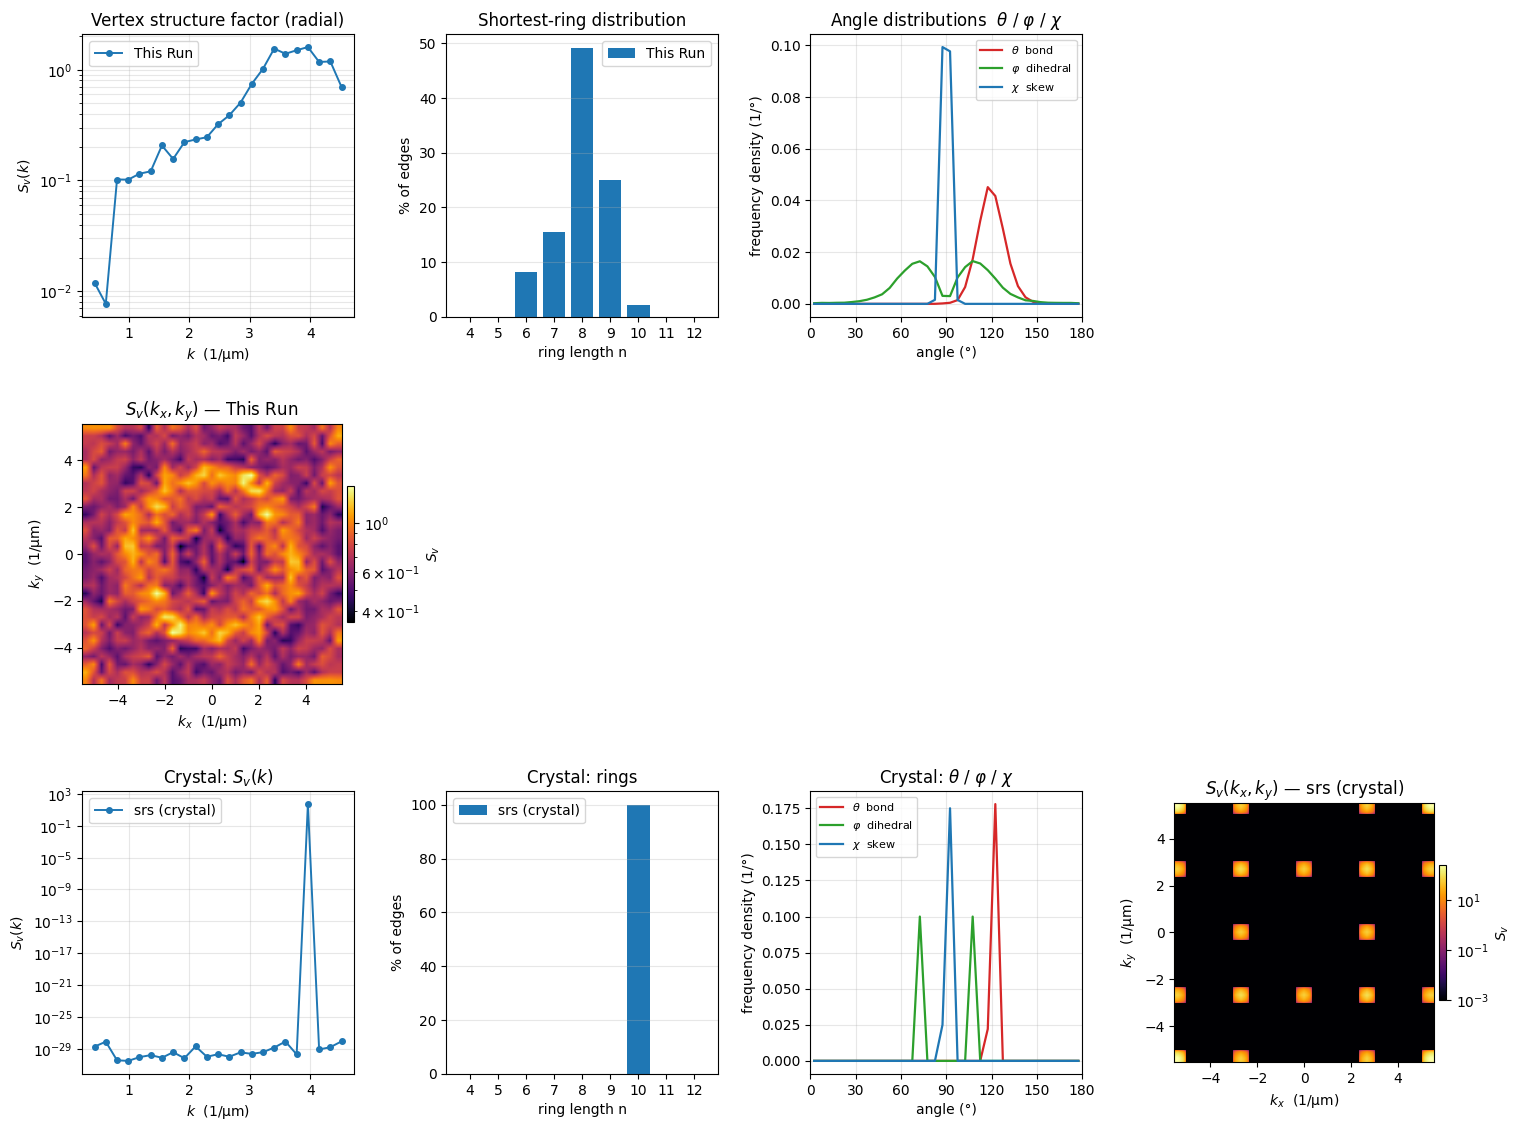

In [6]:
import tools
filename = "./Example/20260624_lsu_fromrandom_N4000_ends.txt"
D0, N = 0.8, 4000
BOX = (N/1000 * 11.44**3)**(1/3)
srs_rods = tools.srs_crystal_rods(num_vertices=N, box=BOX, d0=D0)

results = []
for source, lbl in [
    (srs_rods,                                  'srs (crystal)'),
    # ('Example/lsu_example_ends.txt',            'reference'),
    (filename,                                  'This Run'),
]:
    if lbl == 'reference':
        results.append(tools.analyze_network(
            source, box=11.44, d0=D0, label=lbl, verbose=False,
            k_modes_max_2d=16,
            ))
    else:
        results.append(tools.analyze_network(
            source, box=BOX, d0=D0, label=lbl, verbose=False,
            k_modes_max_2d=16,
            ))

tools._print_comparison(results)

fig, axes = tools.plot_comparison(
    results,
    ring_range=(4, 12),
    sk_logy=True,
    sk_2d_log=True,
    sk_2d_shared_clim=True,
    sk_2d_interp='bilinear',
)
# fig.savefig('Example/lsu_compare_with_srs.png', dpi=150, bbox_inches='tight')


# --- GLOBAL-AMORPHOUS gate: S_v(k) must have NO Bragg peaks ---------------
# This is THE metric the structure must pass: a crystal (or a lightly
# jittered crystal) shows tall, sharp S_v(k) Bragg peaks; the reference
# amorphous network does not. Pass = S_v peak ~< 2.5 and 0 peaks > 3.
import numpy as _np
print('\n=== GLOBAL-AMORPHOUS check: S_v(k) Bragg peaks ===')
for _r in results:
    _sk = _np.array(_r['S_v_k_means']); _sk = _sk[_np.isfinite(_sk)]
    _peak = float(_np.nanmax(_sk)); _nbig = int((_sk > 3).sum())
    _verdict = 'AMORPHOUS' if (_peak < 2.5 and _nbig == 0) else 'CRYSTALLINE-LIKE'
    print(f"  {_r['label']:<14} S_v peak={_peak:5.2f}  Bragg(>3)={_nbig:>2}  "
          f"Φ_22={_r['phi22']:.3f}  S_low={_r['S_low_k2']:.3f}  -> {_verdict}")


In [ ]:
# shutdown(delay_minutes=2)